In [151]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataChunk
from torch.utils.data import DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

device='cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [152]:
df=pd.read_csv('/content/Rice_Classification.csv')
df.head(3)

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1


In [153]:
df.isnull().sum()

,0
id,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0


In [154]:
df.drop('id',axis=1,inplace=True)

In [155]:
df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [156]:
df.shape

(18185, 11)

In [157]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


In [158]:
print(f"The output possibilities are {df['Class'].unique()}")

The output possibilities are [1 0]


In [159]:
df['Class'].value_counts()

,count
Class,
1,9985
0,8200


In [160]:
Original_DataFrame=df.copy()

Normalize data using Max Absolute Scaling

In [161]:
for column in df.columns:
  df[column]=df[column]/df[column].abs().max()

In [162]:
df.head(1)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.66661,0.741661,0.537029,0.844997,0.368316,1.0


In [163]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [164]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [165]:
x_test,x_val,y_test,y_val=train_test_split(x_test,y_test,test_size=0.5,random_state=42)

In [166]:
x_train.shape,x_test.shape,x_val.shape

((12729, 10), (2728, 10), (2728, 10))

Changing the data to pytorch dataset object

In [167]:
class Dataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x.values,dtype=torch.float32).to(device)
    self.y=torch.tensor(y.values,dtype=torch.long).to(device)

  def __len__(self):
    return len(self.x)

  def __getitem__(self,index):
    return self.x[index],self.y[index]

In [168]:
  train_dataset=Dataset(x_train,y_train)
  test_dataset=Dataset(x_test,y_test)
  val_dataset=Dataset(x_val,y_val)

dividing data into batches because models are designed to process data in batches, not the whole dataset at once.



In [169]:
train_dataloader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=True)
val_dataloader=DataLoader(val_dataset,batch_size=32,shuffle=True)

In [170]:
for x,y in train_dataloader:
  print(x)
  print("===============")
  print(y)
  break

tensor([[0.7852, 0.8293, 0.8269, 0.9241, 0.7526, 0.8861, 0.7312, 0.7169, 0.8379,
         0.5690],
        [0.6632, 0.8758, 0.6637, 0.9722, 0.6332, 0.8144, 0.5399, 0.7173, 0.7068,
         0.7486],
        [0.6114, 0.8032, 0.6626, 0.9603, 0.5807, 0.7819, 0.5775, 0.6622, 0.7645,
         0.6877],
        [0.8445, 0.8500, 0.8657, 0.9190, 0.8041, 0.9189, 0.7271, 0.7363, 0.8543,
         0.5571],
        [0.8380, 0.8650, 0.8389, 0.9304, 0.7943, 0.9154, 0.7833, 0.7357, 0.8492,
         0.5850],
        [0.6744, 0.7252, 0.8091, 0.8941, 0.6358, 0.8212, 0.8984, 0.6371, 0.9114,
         0.5085],
        [0.9379, 0.9115, 0.8945, 0.9278, 0.8924, 0.9685, 0.6546, 0.7821, 0.8409,
         0.5781],
        [0.4400, 0.7740, 0.5004, 0.9895, 0.4327, 0.6633, 0.8042, 0.6257, 0.6164,
         0.8776],
        [0.6034, 0.8513, 0.6227, 0.9766, 0.5753, 0.7768, 0.5174, 0.6839, 0.7075,
         0.7757],
        [0.5974, 0.8654, 0.6099, 0.9808, 0.5710, 0.7729, 0.8759, 0.6884, 0.6912,
         0.8050],
        [0

In [171]:
Hidden_Neurons=10
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer=nn.Linear(x.shape[1],Hidden_Neurons)
    self.Linear=nn.Linear(Hidden_Neurons,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,x):
    x=self.input_layer(x)
    x=self.Linear(x)
    x=self.sigmoid(x)
    return x

model=MyModel().to(device)

In [172]:
summary(model,(x.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [173]:
loss_criteria=nn.BCELoss()
optimizer= Adam(model.parameters(),lr=0.0005)

In [174]:
total_loss_train_plot=[]
total_loss_val_plot=[]
total_acc_train_plot=[]
total_acc_val_plot=[]

epochs=10
for epoch in range(epochs):
  total_acc_train= 0
  total_loss_train=0
  total_acc_val=0
  total_loss_val=0

  for data in train_dataloader:
    inputs,labels=data
    y_pred=model(x)

    prediction=model(inputs).squeeze(1)
    batch_loss=loss_criteria(prediction,labels.float())
    total_loss_train+=batch_loss.item()

    batch_acc=(prediction.round()==labels).sum().item()
    total_acc_train+=batch_acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in val_dataloader:
      inputs,labels=data
      prediction=model(inputs).squeeze(1)
      batch_loss=loss_criteria(prediction,labels.float())
      total_loss_val+=batch_loss.item()

      batch_acc=(prediction.round()==labels).sum().item()
      total_acc_val+=batch_acc

  total_loss_train_plot.append(round(total_loss_train/len(train_dataloader),4))
  total_loss_val_plot.append(round(total_loss_val/len(val_dataloader),4))
  total_acc_train_plot.append(round(total_acc_train/len(train_dataset)*100,4))
  total_acc_val_plot.append(round(total_acc_val/len(val_dataset)*100,4))


  print(f'Epoch {epoch+1}/{epochs} | Train Loss: {total_loss_train/len(train_dataloader):.4f} | Train Acc: {total_acc_train/len(train_dataset):.4f} | Val Loss: {total_loss_val/len(val_dataloader):.4f} | Val Acc: {total_acc_val/len(val_dataset):.4f}')

Epoch 1/10 | Train Loss: 0.6647 | Train Acc: 0.7112 | Val Loss: 0.6217 | Val Acc: 0.9564
Epoch 2/10 | Train Loss: 0.5430 | Train Acc: 0.9616 | Val Loss: 0.4480 | Val Acc: 0.9828
Epoch 3/10 | Train Loss: 0.3627 | Train Acc: 0.9793 | Val Loss: 0.2814 | Val Acc: 0.9853
Epoch 4/10 | Train Loss: 0.2313 | Train Acc: 0.9817 | Val Loss: 0.1834 | Val Acc: 0.9861
Epoch 5/10 | Train Loss: 0.1588 | Train Acc: 0.9827 | Val Loss: 0.1303 | Val Acc: 0.9839
Epoch 6/10 | Train Loss: 0.1189 | Train Acc: 0.9832 | Val Loss: 0.1018 | Val Acc: 0.9864
Epoch 7/10 | Train Loss: 0.0954 | Train Acc: 0.9844 | Val Loss: 0.0851 | Val Acc: 0.9861
Epoch 8/10 | Train Loss: 0.0807 | Train Acc: 0.9847 | Val Loss: 0.0719 | Val Acc: 0.9857
Epoch 9/10 | Train Loss: 0.0707 | Train Acc: 0.9850 | Val Loss: 0.0650 | Val Acc: 0.9861
Epoch 10/10 | Train Loss: 0.0639 | Train Acc: 0.9853 | Val Loss: 0.0601 | Val Acc: 0.9861


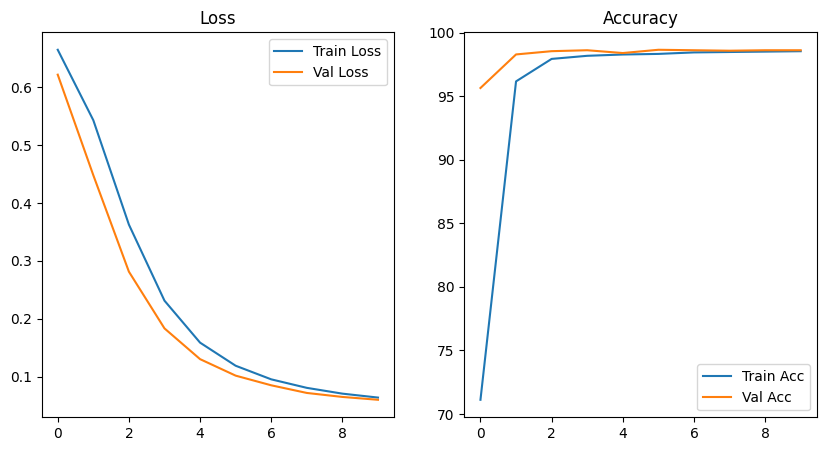

In [175]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(total_loss_train_plot, label='Train Loss')
plt.plot(total_loss_val_plot, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(total_acc_train_plot, label='Train Acc')
plt.plot(total_acc_val_plot, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [176]:
with torch.no_grad():
    y_pred_list = []
    y_true_list = []
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        y_pred = model(inputs)
        y_pred_list.extend(y_pred.round().cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(y_true_list, y_pred_list)}")

Test Accuracy: 0.9879032258064516


In [181]:
area = 2353/Original_DataFrame['Area'].abs().max()
MajorAxisLength = 81/Original_DataFrame['MajorAxisLength'].abs().max()
MinorAxisLength = 42/Original_DataFrame['MinorAxisLength'].abs().max()
Eccentricity = 32/Original_DataFrame['Eccentricity'].abs().max()
ConvexArea = 12/Original_DataFrame['ConvexArea'].abs().max()
EquivDiameter = 33/Original_DataFrame['EquivDiameter'].abs().max()
Extent = 98/Original_DataFrame['Extent'].abs().max()
Perimeter = 927/Original_DataFrame['Perimeter'].abs().max()
Roundness = 677/Original_DataFrame['Roundness'].abs().max()
AspectRatio = 24/Original_DataFrame['AspectRation'].abs().max()

Prediction = model(torch.tensor([area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness,AspectRatio],dtype=torch.float32).to(device))

In [182]:
print(Prediction)

tensor([0.], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [183]:
if Prediction.round().item() == 1:
    print("The model predicts that the rice is of class 1.")
else:
    print("The model predicts that the rice is of class 0.")

The model predicts that the rice is of class 0.


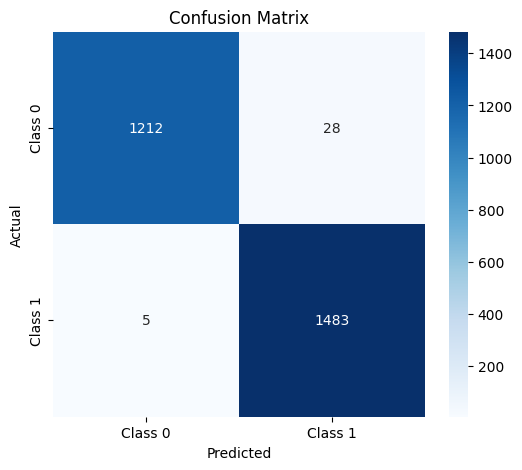

In [184]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_true_list, y_pred_list)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()